In [774]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [775]:
# add data set
space_df = pd.read_csv("data/Master_Space_Data_All.txt")
space_df.head()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission
0,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 25 2026 14:12 UTC,Falcon 9 Block 5 | Starlink Group 17-26,StatusActive,52.0,Success
1,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 24 2026 23:04 UTC,Falcon 9 Block 5 | Starlink Group 6-110,StatusActive,52.0,Success
2,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 21 2026 13:42 UTC,Falcon 9 Block 5 | Starlink Group 11-5,StatusActive,52.0,Success
3,CASC,"Xichang Satellite Launch Center, China",Feb 21 2026 09:30 UTC,Long March 2C | Geely-03 Group 01,StatusActive,30.0,Success
4,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 19 2026 10:48 UTC,Falcon 9 Block 5 | Starlink Group 6-109,StatusActive,52.0,Success


In [ ]:
# convert into numeric, removing commas and coercing errors to NaN
space_df['Price'] = pd.to_numeric(space_df['Price'].astype(str).str.replace(',', ''), errors='coerce')

In [777]:
space_df.head()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission
0,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 25 2026 14:12 UTC,Falcon 9 Block 5 | Starlink Group 17-26,StatusActive,52.0,Success
1,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 24 2026 23:04 UTC,Falcon 9 Block 5 | Starlink Group 6-110,StatusActive,52.0,Success
2,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 21 2026 13:42 UTC,Falcon 9 Block 5 | Starlink Group 11-5,StatusActive,52.0,Success
3,CASC,"Xichang Satellite Launch Center, China",Feb 21 2026 09:30 UTC,Long March 2C | Geely-03 Group 01,StatusActive,30.0,Success
4,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 19 2026 10:48 UTC,Falcon 9 Block 5 | Starlink Group 6-109,StatusActive,52.0,Success


In [778]:
space_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5319 entries, 0 to 5318
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company Name    5319 non-null   object 
 1   Location        5319 non-null   object 
 2   Datum           5319 non-null   object 
 3   Detail          5318 non-null   object 
 4   Status Rocket   5316 non-null   object 
 5   Price           5315 non-null   float64
 6   Status Mission  5315 non-null   object 
dtypes: float64(1), object(6)
memory usage: 291.0+ KB


In [ ]:
# fill NaN values with 0 and convert to float
space_df['Price'] = space_df['Price'].fillna(0).astype(float)

In [781]:
print(space_df.columns)

Index(['Company Name', 'Location', 'Datum', 'Detail', 'Status Rocket', 'Price',
       'Status Mission'],
      dtype='object')


In [ ]:
# extract country from Location column
space_df['countries'] = space_df['Location'].str.split(',').str[-1].str.strip()

In [ ]:
# take states out of USA
usa_states = ['CA', 'FL', 'TX', 'Texas', 'New Mexico', 'Virginia']
space_df['countries'] = space_df['countries'].replace(usa_states, 'USA')

In [784]:
print(space_df[['Location', 'countries']].head())

                                 Location countries
0              SLC-4E, Vandenberg SFB, CA       USA
1          SLC-40, Cape Canaveral SFS, FL       USA
2              SLC-4E, Vandenberg SFB, CA       USA
3  Xichang Satellite Launch Center, China     China
4          SLC-40, Cape Canaveral SFS, FL       USA


In [785]:
space_df.sample()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission,countries
2331,Boeing,"SLC-17B, Cape Canaveral AFS, Florida, USA","Sat Jan 10, 1998 00:32 UTC",Delta II 7925 | Skynet 4D,StatusRetired,0.0,Success,USA


In [786]:
space_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5319 entries, 0 to 5318
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company Name    5319 non-null   object 
 1   Location        5319 non-null   object 
 2   Datum           5319 non-null   object 
 3   Detail          5318 non-null   object 
 4   Status Rocket   5316 non-null   object 
 5   Price           5319 non-null   float64
 6   Status Mission  5315 non-null   object 
 7   countries       5319 non-null   object 
dtypes: float64(1), object(7)
memory usage: 332.6+ KB


In [787]:
# space_df['Date'] = pd.to_datetime(space_df['Datum'], errors='coerce', utc=True).dt.year

In [ ]:
# extract year from Datum column using regex
def extract_year(text):
    if pd.isna(text):
        return None
    match = re.search(r'(19\d{2}|20\d{2})', str(text))
    return int(match.group(1)) if match else None

space_df['date'] = space_df['Datum'].apply(extract_year)

In [789]:
space_df.sample()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission,countries,date
4037,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Wed May 15, 1974 08:30 UTC",Soyuz U | Cosmos 652,StatusRetired,0.0,Success,Kazakhstan,1974.0


In [790]:
space_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5319 entries, 0 to 5318
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company Name    5319 non-null   object 
 1   Location        5319 non-null   object 
 2   Datum           5319 non-null   object 
 3   Detail          5318 non-null   object 
 4   Status Rocket   5316 non-null   object 
 5   Price           5319 non-null   float64
 6   Status Mission  5315 non-null   object 
 7   countries       5319 non-null   object 
 8   date            5134 non-null   float64
dtypes: float64(2), object(7)
memory usage: 374.1+ KB


In [ ]:
# convert date to Int64 
space_df['date'] = space_df['date'].astype('Int64')

In [792]:
space_df.head()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission,countries,date
0,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 25 2026 14:12 UTC,Falcon 9 Block 5 | Starlink Group 17-26,StatusActive,52.0,Success,USA,2026
1,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 24 2026 23:04 UTC,Falcon 9 Block 5 | Starlink Group 6-110,StatusActive,52.0,Success,USA,2026
2,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 21 2026 13:42 UTC,Falcon 9 Block 5 | Starlink Group 11-5,StatusActive,52.0,Success,USA,2026
3,CASC,"Xichang Satellite Launch Center, China",Feb 21 2026 09:30 UTC,Long March 2C | Geely-03 Group 01,StatusActive,30.0,Success,China,2026
4,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 19 2026 10:48 UTC,Falcon 9 Block 5 | Starlink Group 6-109,StatusActive,52.0,Success,USA,2026


In [793]:
#adding lat and lon columns

location_coords = {
    "Plesetsk Cosmodrome": [64.6970, 40.2320],
    "Cape Canaveral": [28.4962, -80.5772],
    "Baikonur Cosmodrome": [45.9697, 63.3042],
    "Vandenberg SFB": [34.6370, -120.6146],
    "Vandenberg AFB": [34.6370, -120.6146],
    "Vandenberg": [34.6370, -120.6146],
    "French Guiana": [5.2380, -52.7762],
    "Kennedy Space Center": [28.5746, -80.6520],
    "Jiuquan": [40.9861, 100.2083],
    "Xichang": [27.9006, 102.2435],
    "Kapustin Yar": [48.6437, 45.7721],
    "Taiyuan": [38.8487, 111.6080],
    "Tanegashima": [30.4018, 130.9774],
    "Sriharikota": [13.7406, 80.2340],
    "Uchinoura": [31.2515, 131.0762],
    "Wallops Flight Facility": [37.9342, -75.4724],
    "Mahia Peninsula": [-39.2380, 177.8746],
    "Mahia, New Zealand": [-39.2380, 177.8746],
    "Wenchang": [19.5768, 110.7480],
    "Corn Ranch": [31.4230, -104.7571],
    "Vostochny Cosmodrome": [51.8495, 128.3552],
    "Semnan": [35.9543, 53.8075],
    "Yellow Sea": [36.7039, 121.2359],
    "Palmachim": [31.9064, 34.6933],
    "Kwajalein Atoll": [8.9836, 167.5780],
    "Kodiak Launch Complex": [57.4309, -152.3563],
    "Starbase": [25.9923, -97.1848],
    "San Marco Platform": [-2.9955, 40.1948],
    "Woomera": [-31.0688, 136.4426],
    "Point Mugu": [34.0870, -119.0610],
    "Edwards AFB": [34.9175, -117.8912],
    "Naro Space Center": [34.4536, 127.5179],
    "Spaceport America": [32.9903, -106.9750],
    "Hammaguir": [30.8678, -3.0436],
    "Mojave Air and Space Port": [35.0293, -118.1059],
    "Sohae": [39.6683, 124.7070],
    "Gran Canaria": [27.9252, -15.6214],
    "S. Korea": [36.6432, 127.2068]
}

# 2. Define a function to find the match
def get_lat_lon(loc_string):
    for key, coords in location_coords.items():
        if key.lower() in str(loc_string).lower():
            return pd.Series(coords)
    return pd.Series([None, None])

# 3. Apply the function to create 'Lat' and 'Lon' columns
# Assuming your dataframe is named 'space_df' and has a column 'Location'
space_df[['Lat', 'Lon']] = space_df['Location'].apply(get_lat_lon)



In [794]:
space_df.head()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission,countries,date,Lat,Lon
0,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 25 2026 14:12 UTC,Falcon 9 Block 5 | Starlink Group 17-26,StatusActive,52.0,Success,USA,2026,34.6370,-120.6146
1,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 24 2026 23:04 UTC,Falcon 9 Block 5 | Starlink Group 6-110,StatusActive,52.0,Success,USA,2026,28.4962,-80.5772
2,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 21 2026 13:42 UTC,Falcon 9 Block 5 | Starlink Group 11-5,StatusActive,52.0,Success,USA,2026,34.6370,-120.6146
3,CASC,"Xichang Satellite Launch Center, China",Feb 21 2026 09:30 UTC,Long March 2C | Geely-03 Group 01,StatusActive,30.0,Success,China,2026,27.9006,102.2435
4,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 19 2026 10:48 UTC,Falcon 9 Block 5 | Starlink Group 6-109,StatusActive,52.0,Success,USA,2026,28.4962,-80.5772


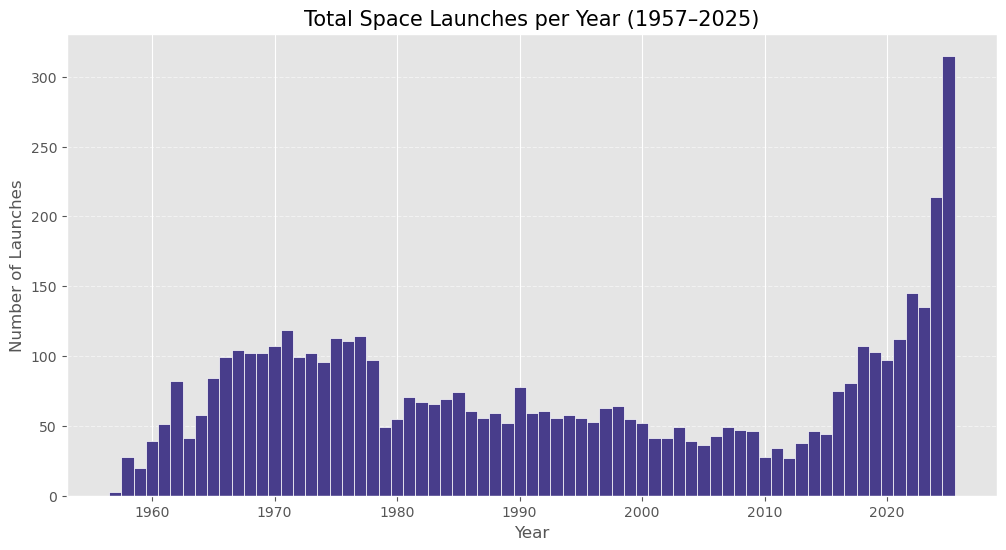

In [795]:
df_filtered = space_df[space_df['date'] <= 2025]

# 3. Plot the distribution
plt.figure(figsize=(12, 6))
min_yr, max_yr = int(df_filtered['date'].min()), int(df_filtered['date'].max())

plt.hist(df_filtered['date'], bins=range(min_yr, max_yr + 2), 
         color='darkslateblue', edgecolor='white', align='left')

plt.title('Total Space Launches per Year (1957–2025)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

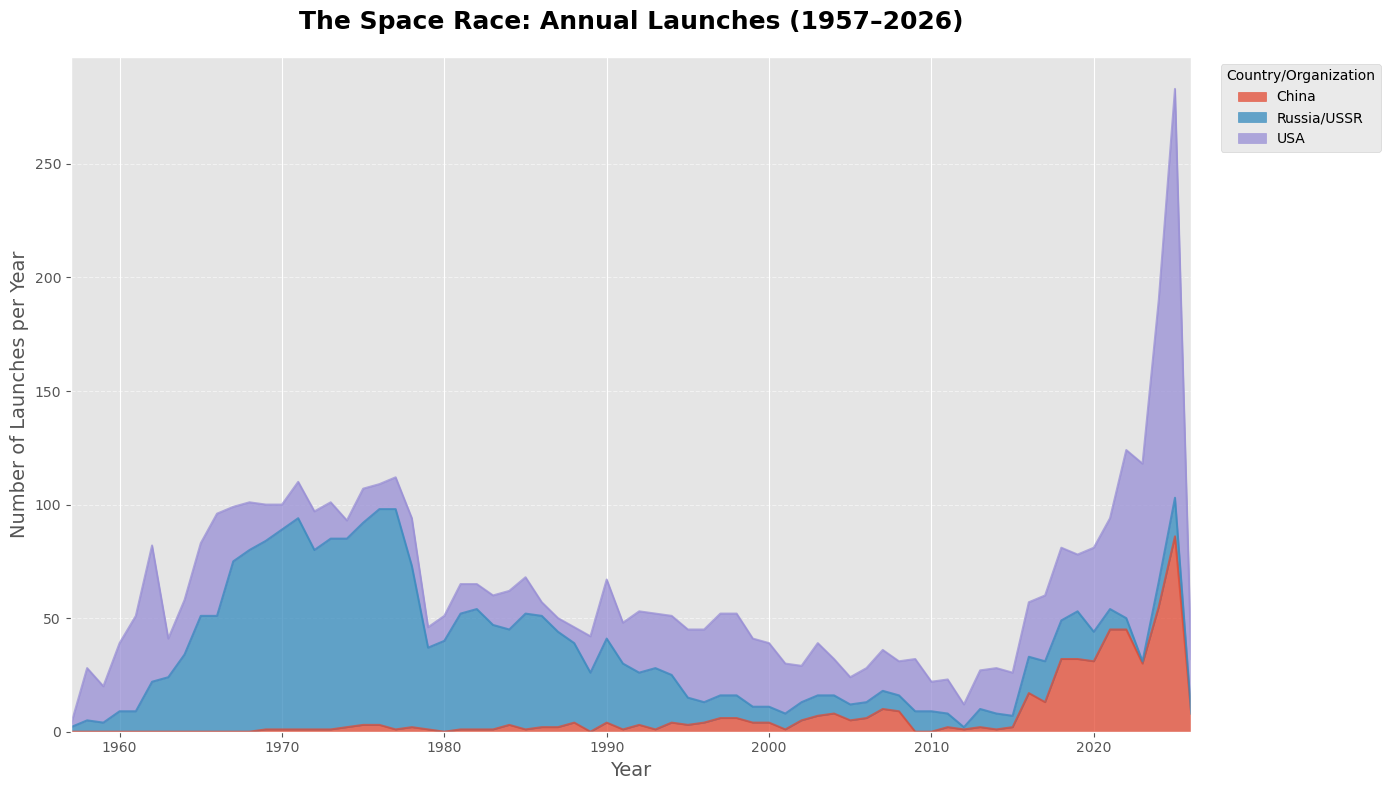

In [796]:
# space_df['date'] = pd.to_numeric(space_df['date'], errors='coerce')
# space_df['countries'] = space_df['countries'].str.strip()

space_df['countries'] = space_df['countries'].replace('Kazakhstan', 'Russia/USSR').replace('Russia', 'Russia/USSR')

# Cleaning: Focus on the major players to keep the graph readable
# Filter for years 1957 to 2026
df_filtered = space_df[(space_df['date'] >= 1957) & (space_df['date'] <= 2026)].copy()

# Focus on the Top  countries by launch count
top_countries = df_filtered.groupby('countries').size().nlargest(3).index
df_top = df_filtered[df_filtered['countries'].isin(top_countries)]

# 3. Create the Pivot Table (Crucial for the area chart)
# Each year is an index, each country is a column
# pivot_df = df_top.groupby(['date', 'countries']).size().unstack(fill_value=0)
pivot_df.plot(kind='line', ax=ax, linewidth=2)

# 4. Create the Visualization
plt.style.use('ggplot') # Makes the chart look modern
fig, ax = plt.subplots(figsize=(14, 8))

# Create the Stacked Area Plot
pivot_df.plot(kind='area', stacked=True, ax=ax, alpha=0.75)

# Formatting
ax.set_title('The Space Race: Annual Launches (1957–2026)', fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel('Number of Launches per Year', fontsize=14)
ax.set_xlabel('Year', fontsize=14)
ax.legend(title='Country/Organization', loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_xlim(pivot_df.index.min(), pivot_df.index.max())
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

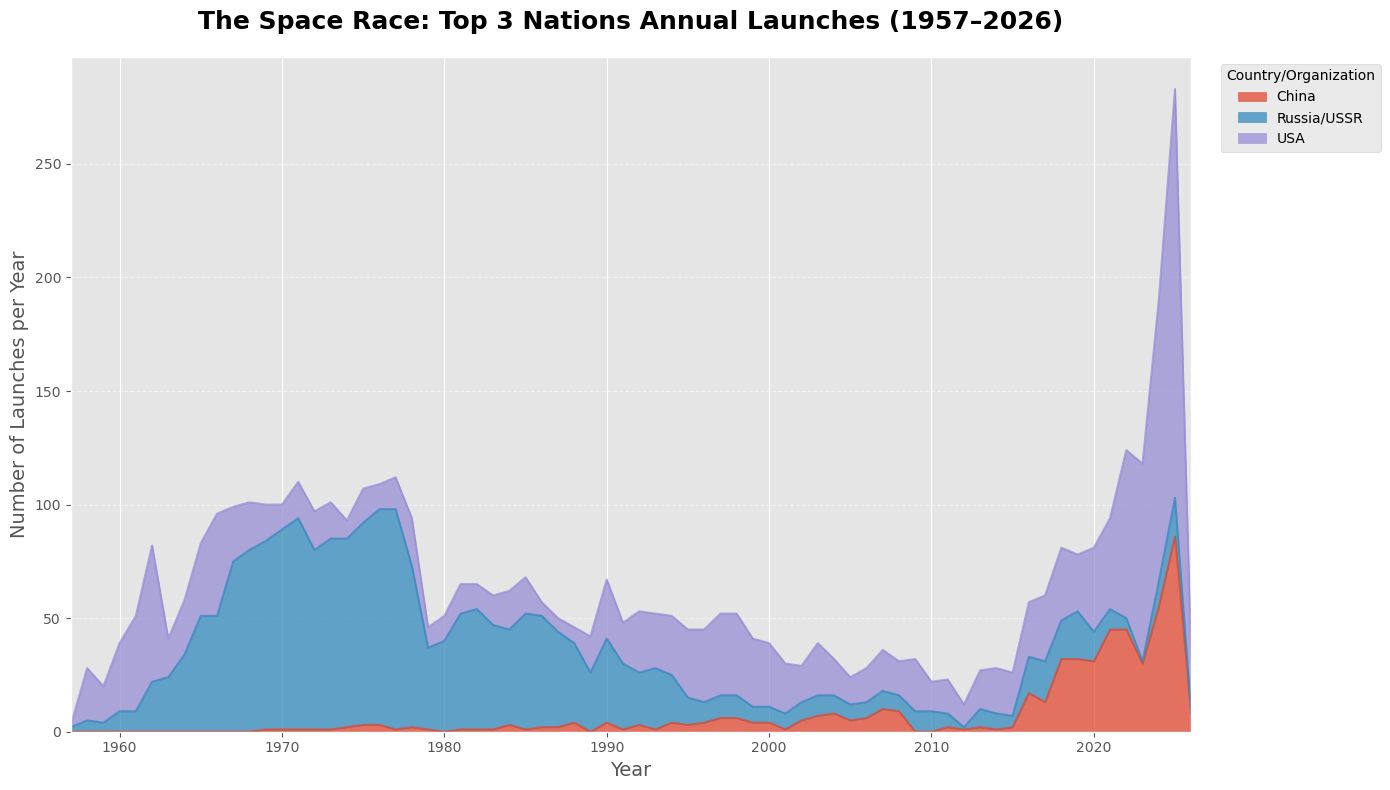

In [797]:
import matplotlib.pyplot as plt

# 1. Clean and Merge Russia/USSR
space_df['countries'] = space_df['countries'].str.strip()
space_df['countries'] = space_df['countries'].replace({'Kazakhstan': 'Russia/USSR', 'Russia': 'Russia/USSR'})

# 2. Filter years and identify the Top 3 countries
df_filtered = space_df[(space_df['date'] >= 1957) & (space_df['date'] <= 2026)].copy()
top_countries = df_filtered.groupby('countries').size().nlargest(3).index
df_top = df_filtered[df_filtered['countries'].isin(top_countries)]

# 3. Create the Pivot Table for the Top 3
# This organizes the data so each of the 3 countries has its own column
pivot_df = df_top.groupby(['date', 'countries']).size().unstack(fill_value=0)

# 4. Create the Visualization
plt.style.use('ggplot') 
fig, ax = plt.subplots(figsize=(14, 8))

# Create the Stacked Area Plot using the Top 3 data
pivot_df.plot(kind='area', stacked=True, ax=ax, alpha=0.75)

# Formatting
ax.set_title('The Space Race: Top 3 Nations Annual Launches (1957–2026)', fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel('Number of Launches per Year', fontsize=14)
ax.set_xlabel('Year', fontsize=14)
ax.legend(title='Country/Organization', loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_xlim(pivot_df.index.min(), pivot_df.index.max())
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [798]:
usa_1970 = space_df[(space_df['date'] == 1970) & (space_df['Location'].str.contains("USA", na=False))]


print(f"Total USA launches in 1970: {len(usa_1970)}")
# print(usa_1970[['Company Name', 'Location', 'Datum', 'Status Mission']])

Total USA launches in 1970: 11


In [799]:
russia_1970 = space_df[(space_df['date'] == 1970) & (space_df['Location'].str.contains("Russia|Kazakhstan", na=False))]


print(f"Total Russia launches in 1970: {len(russia_1970)}")

Total Russia launches in 1970: 88


In [800]:
import plotly.express as px
# 1. Prepare the data (Reset index so 'Year' is a column for Plotly)
plot_data = pivot_df.reset_index().melt(id_vars='date', var_name='Country', value_name='Launches')

# 2. Create the interactive Area Chart
fig = px.area(plot_data, 
              x="date", 
              y="Launches", 
              color="Country",
              title="The Space Race: Annual Launches (Hover for Details)",
              labels={"Launches": "Number of Launches", "date": "Year"})

# 3. Improve the hover experience
fig.update_layout(
    hovermode="x unified",  # Shows all countries in one box when hovering
    xaxis_title="Year",
    yaxis_title="Total Launches",
    legend_title="Country"
)

fig.show()

In [801]:
import plotly.express as px
import pandas as pd

# 1. READJUSTED DATA: 1970 Counts + Your High-Precision Coordinates
data = {
    'Spaceport': [
        'Plesetsk Cosmodrome, Russia', 'Cape Canaveral, FL, USA', 'Baikonur Cosmodrome, Kazakhstan', 
        'Vandenberg SFB, CA, USA', 'French Guiana, France', 'Kennedy Space Center, FL, USA', 
        'Kapustin Yar, Russia', 'Uchinoura, Japan', 'Jiuquan, China', 
        'San Marco Platform, Kenya', 'Woomera, Australia', 'Wallops Flight Facility, VA, USA'
    ],
    'Launches': [
        81, 28, 31, 23, 5, 3, 8, 1, 1, 1, 1, 2  # Historically accurate counts for 1970
    ],
    'Lat': [
        64.697039, 28.496279, 45.969713, 34.637077, 5.238019, 28.574602, 
        48.643798, 31.251505, 40.986111, -2.995544, -31.068851, 37.934263
    ],
    'Lon': [
        40.232021, -80.577210, 63.304277, -120.614624, -52.776268, -80.652004, 
        45.772124, 131.076202, 100.208351, 40.194866, 136.442654, -75.472412
    ]
}
df_map = pd.DataFrame(data)

# 2. Create the Density Heatmap (Static & Intense)
fig = px.density_mapbox(df_map, 
                        lat='Lat', 
                        lon='Lon', 
                        z='Launches', 
                        radius=45,             # High radius makes the "heat" look darker and thicker
                        range_color=[0, 30],   # Lowered max: Anything over 30 launches hits Dark Red
                        center=dict(lat=30, lon=10), 
                        zoom=1,
                        mapbox_style="open-street-map", 
                        title="1970 Global Space Launch Intensity",
                        # Custom color scale: White -> Red -> Dark Red
                        color_continuous_scale=[[0, 'white'], [0.3, 'red'], [1, 'darkred']])

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    dragmode=False, # Disables interaction for a "Solid" look
)

# 3. Show as a static plot
fig.show(config={'staticPlot': True})

C:\Users\nmill\AppData\Local\Temp\ipykernel_26972\219304330.py:27: DeprecationWarning:

*density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [802]:
import plotly.express as px

# 1. Filter your main dataset for the specific year
# (Assuming your year column is named 'Year')
df_1970 = space_df[space_df['date'] == 1970].copy()

# 2. Group by the locations to get the 'Heat' (Launch Count)
# We include Lat and Lon in the groupby so they stay in the result
df_heat = df_1970.groupby(['Location', 'Lat', 'Lon']).size().reset_index(name='Launches')

# 3. Create the Intense Map
fig = px.density_mapbox(df_heat, 
                        lat='Lat', 
                        lon='Lon', 
                        z='Launches', 
                        radius=40,             # Thick, dark "ink" blots
                        range_color=[0, 50],    # Lowered max to make 1970 pop
                        center=dict(lat=30, lon=0), 
                        zoom=1,
                        mapbox_style="open-street-map",
                        title="1970 Global Space Launch Intensity",
                        # Custom Scale: White to Dark Red
                        color_continuous_scale=[[0, 'white'], [0.3, 'red'], [1, 'darkred']])

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    dragmode=False
)

# Show as a solid, static image
fig.show(config={'staticPlot': True})

C:\Users\nmill\AppData\Local\Temp\ipykernel_26972\3296674720.py:12: DeprecationWarning:

*density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [803]:


# 1. Filter your main dataset for the specific year
# (Assuming your year column is named 'Year')
df_2020 = space_df[space_df['date'] == 2020].copy()

# 2. Group by the locations to get the 'Heat' (Launch Count)
# We include Lat and Lon in the groupby so they stay in the result
df_heat = df_2020.groupby(['Location', 'Lat', 'Lon']).size().reset_index(name='Launches')

# 3. Create the Intense Map
fig = px.density_mapbox(df_heat, 
                        lat='Lat', 
                        lon='Lon', 
                        z='Launches', 
                        radius=40,             # Thick, dark "ink" blots
                        range_color=[0, 50],    # Lowered max to make 1970 pop
                        center=dict(lat=30, lon=0), 
                        zoom=1,
                        mapbox_style="open-street-map",
                        title="2020 Global Space Launch Intensity",
                        # Custom Scale: White to Dark Red
                        color_continuous_scale=[[0, 'white'], [0.3, 'red'], [1, 'darkred']])

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    dragmode=False
)

# Show as a solid, static image
fig.show(config={'staticPlot': True})

C:\Users\nmill\AppData\Local\Temp\ipykernel_26972\469482187.py:10: DeprecationWarning:

*density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [804]:

# 1. Filter your main dataset for the specific year
# (Assuming your year column is named 'Year')
df_2025 = space_df[space_df['date'] == 2025].copy()

# 2. Group by the locations to get the 'Heat' (Launch Count)
# We include Lat and Lon in the groupby so they stay in the result
df_heat = df_2025.groupby(['Location', 'Lat', 'Lon']).size().reset_index(name='Launches')

# 3. Create the Intense Map
fig = px.density_mapbox(df_heat, 
                        lat='Lat', 
                        lon='Lon', 
                        z='Launches', 
                        radius=40,             # Thick, dark "ink" blots
                        range_color=[0, 150],    # Lowered max to make 1970 pop
                        center=dict(lat=30, lon=0), 
                        zoom=1,
                        mapbox_style="open-street-map",
                        title="2025 Global Space Launch Intensity",
                        # Custom Scale: White to Dark Red
                        color_continuous_scale=[[0, 'white'], [0.3, 'red'], [1, 'darkred']])

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    dragmode=False
)

# Show as a solid, static image
fig.show(config={'staticPlot': True})

C:\Users\nmill\AppData\Local\Temp\ipykernel_26972\305298615.py:10: DeprecationWarning:

*density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



<Axes: xlabel='date'>

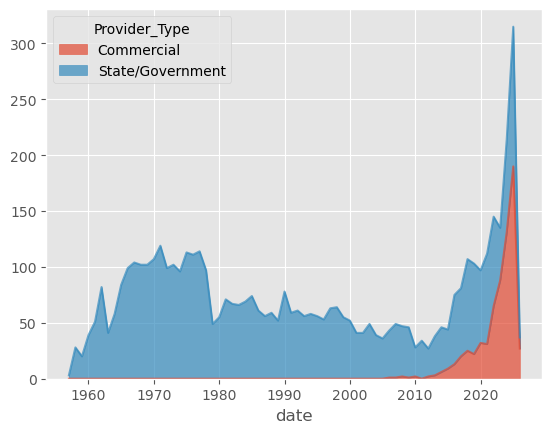

In [806]:
# Create a simplified 'Type' column
def categorize_provider(company):
    commercial_list = ['SpaceX', 'Rocket Lab', 'Blue Origin', 'Galactic Energy', 'i-Space']
    if company in commercial_list:
        return 'Commercial'
    return 'State/Government'

space_df['Provider_Type'] = space_df['Company Name'].apply(categorize_provider)

# Filter for 2010-2026
df_modern = space_df[(space_df['date'] >= 1957) & (space_df['date'] <= 2026)]

# Group and plot to see the transition
pivot_modern = df_modern.groupby(['date', 'Provider_Type']).size().unstack(fill_value=0)
pivot_modern.plot(kind='area', stacked=True, alpha=0.7)

In [810]:
unique_companies = df['Company Name'].unique()
print(unique_companies)

['SpaceX' 'CASC' 'Arianespace' 'ULA' 'Galactic Energy' 'AST SpaceMobile'
 'JAXA' 'ESA' 'ExPace' 'LandSpace' 'SIAS' 'KARI' 'ISRO' 'ISA'
 'Blue Origin' 'CAS Space' 'Orienspace' 'i-Space' 'CGSTL' 'NADA'
 'China Rocket' 'MHI' 'Amazon/ULA' 'Relativity Space' 'NASA' 'Astra'
 'Roscosmos' 'Northrop' 'IAI' 'Virgin Orbit' 'VKS RF' 'Exos' 'ILS'
 'OneSpace' 'Landspace' 'Eurockot' 'Land Launch' 'CASIC' 'KCST'
 'Khrunichev' 'Kosmotras' 'Boeing' 'ISAS' 'Lockheed' 'Starsem' 'RVSN USSR'
 'EER' 'MITT' 'Martin Marietta' 'General Dynamics' 'Yuzhmash' 'Douglas'
 'CNES' 'CECLES' 'RAE' 'UT' 'OKB-586' 'AMBA' "Arm??e de l'Air"
 'US Air Force' 'US Navy']
